In [19]:
pip install torch torchvision torchaudio numpy matplotlib tqdm jupyter ipykernel ipywidgets


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [20]:
import chess
import chess.pgn
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from pathlib import Path
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [21]:
class ResidualBlock(nn.Module):
    """Residual block with batch normalization"""
    def __init__(self, channels=256):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        
    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        x = F.relu(x)
        return x

class ImprovedAlphaZeroNet(nn.Module):
    """Enhanced architecture with residual blocks and better capacity"""
    def __init__(self, input_channels=20, board_size=8, num_actions=4288, num_res_blocks=10, channels=256):
        super().__init__()
        # Initial convolutional block
        self.conv_block = nn.Sequential(
            nn.Conv2d(input_channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU()
        )
        
        # Residual tower
        self.res_blocks = nn.ModuleList([
            ResidualBlock(channels) for _ in range(num_res_blocks)
        ])
        
        # Policy head
        self.policy_conv = nn.Conv2d(channels, 32, 1)
        self.policy_bn = nn.BatchNorm2d(32)
        self.policy_fc = nn.Linear(32 * board_size * board_size, num_actions)
        
        # Value head
        self.value_conv = nn.Conv2d(channels, 32, 1)
        self.value_bn = nn.BatchNorm2d(32)
        self.value_fc1 = nn.Linear(32 * board_size * board_size, 256)
        self.value_fc2 = nn.Linear(256, 1)
        
    def forward(self, x):
        # Initial conv
        x = self.conv_block(x)
        
        # Residual tower
        for block in self.res_blocks:
            x = block(x)
        
        # Policy head
        policy = F.relu(self.policy_bn(self.policy_conv(x)))
        policy = policy.view(policy.size(0), -1)
        policy = self.policy_fc(policy)
        
        # Value head
        value = F.relu(self.value_bn(self.value_conv(x)))
        value = value.view(value.size(0), -1)
        value = F.relu(self.value_fc1(value))
        value = torch.tanh(self.value_fc2(value))
        
        return policy, value

model = ImprovedAlphaZeroNet().to(device)
print(f"[INFO] Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")


[INFO] Model initialized with 21,186,177 parameters


In [22]:
def encode_board(board: chess.Board):
    """
    Enhanced board encoding with richer features (20 channels total):
    - Channels 0-5: Own pieces (P, N, B, R, Q, K)
    - Channels 6-11: Opponent pieces (P, N, B, R, Q, K)
    - Channel 12: Repetition indicator (0 none, 0.5 twofold, 1.0 threefold)
    - Channel 13: En passant square
    - Channel 14: Castling rights (kingside)
    - Channel 15: Castling rights (queenside)
    - Channel 16: Side to move (all 1s if white, all 0s if black)
    - Channel 17: Move count / 100 (game phase indicator)
    - Channel 18: Attacked squares by own pieces
    - Channel 19: Attacked squares by opponent pieces
    """
    planes = np.zeros((20, 8, 8), dtype=np.float32)

    # Piece positions (channels 0-11)
    for sq, piece in board.piece_map().items():
        row = 7 - (sq // 8)
        col = sq % 8

        if piece.color == board.turn:
            # Own pieces (0-5)
            channel = piece.piece_type - 1
        else:
            # Opponent pieces (6-11)
            channel = piece.piece_type - 1 + 6

        planes[channel, row, col] = 1.0

    # Repetition indicator (channel 12)
    rep_val = 0.0
    try:
        if board.is_repetition(3):
            rep_val = 1.0
        elif board.is_repetition(2):
            rep_val = 0.5
        elif board.can_claim_threefold_repetition():
            rep_val = 1.0
    except Exception:
        rep_val = 0.0
    planes[12, :, :] = rep_val

    # En passant square (channel 13)
    if board.ep_square is not None:
        row = 7 - (board.ep_square // 8)
        col = board.ep_square % 8
        planes[13, row, col] = 1.0

    # Castling rights (channels 14-15)
    if board.turn == chess.WHITE:
        if board.has_kingside_castling_rights(chess.WHITE):
            planes[14, :, :] = 1.0
        if board.has_queenside_castling_rights(chess.WHITE):
            planes[15, :, :] = 1.0
    else:
        if board.has_kingside_castling_rights(chess.BLACK):
            planes[14, :, :] = 1.0
        if board.has_queenside_castling_rights(chess.BLACK):
            planes[15, :, :] = 1.0

    # Side to move (channel 16)
    planes[16, :, :] = 1.0 if board.turn == chess.WHITE else 0.0

    # Move count / game phase (channel 17)
    planes[17, :, :] = min(board.fullmove_number / 100.0, 1.0)

    # Attacked squares (channels 18-19)
    for sq in range(64):
        row = 7 - (sq // 8)
        col = sq % 8

        # Check if square is attacked by current player
        if board.is_attacked_by(board.turn, sq):
            planes[18, row, col] = 1.0

        # Check if square is attacked by opponent
        if board.is_attacked_by(not board.turn, sq):
            planes[19, row, col] = 1.0

    return torch.tensor(planes, device=device)


In [23]:
uci_to_idx = {}
idx_to_uci = []

def build_move_index():
    global uci_to_idx, idx_to_uci
    all_moves = []
    for a in range(64):
        for b in range(64):
            if a != b:
                all_moves.append(chess.Move(a, b))
    promos = [chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT]
    for a in range(64):
        rank = a // 8
        if rank == 6:
            for to_sq in range(56,64):
                for p in promos:
                    all_moves.append(chess.Move(a,to_sq,p))
    all_moves = sorted(all_moves,key=lambda m: m.uci())
    idx_to_uci = [m.uci() for m in all_moves]
    uci_to_idx = {m.uci():i for i,m in enumerate(all_moves)}
    print(f"[INFO] Move index built with {len(idx_to_uci)} actions.")

build_move_index()

def move_to_index(move: chess.Move):
    return uci_to_idx.get(move.uci(),0)


[INFO] Move index built with 4288 actions.


In [24]:
class Node:
    def __init__(self, parent=None, prior=0.0):
        self.parent = parent
        self.children = {}
        self.N = 0
        self.W = 0
        self.Q = 0
        self.P = prior

def add_dirichlet_noise(priors, alpha=0.3, epsilon=0.25):
    """Add Dirichlet noise for exploration during self-play"""
    noise = np.random.dirichlet([alpha] * len(priors))
    return [(1 - epsilon) * p + epsilon * n for p, n in zip(priors, noise)]

def mcts(board, simulations=100, c_puct=2.0, temperature=1.0, add_noise=False):
    """
    Improved MCTS with:
    - Higher simulation count
    - Better c_puct for exploration/exploitation balance
    - Temperature-based move selection
    - Optional Dirichlet noise for exploration
    """
    root = Node()
    
    for _ in range(simulations):
        node = root
        sim_board = board.copy()
        search_path = [node]

        # Selection - traverse tree with UCB
        while node.children and not sim_board.is_game_over():
            # UCB formula: Q + c_puct * P * sqrt(parent_N) / (1 + child_N)
            move, node = max(
                node.children.items(),
                key=lambda kv: kv[1].Q + c_puct * kv[1].P * np.sqrt(node.N) / (1 + kv[1].N)
            )
            sim_board.push(move)
            search_path.append(node)

        # Check if game ended
        if sim_board.is_game_over():
            result = sim_board.result()
            if result == "1-0":
                value = 1.0 if sim_board.turn == chess.BLACK else -1.0
            elif result == "0-1":
                value = 1.0 if sim_board.turn == chess.WHITE else -1.0
            else:
                value = 0.0
        else:
            # Evaluate with neural network
            state = encode_board(sim_board).unsqueeze(0)
            with torch.no_grad():
                log_probs, value = model(state)
            
            value = float(value.item())
            probs = F.softmax(log_probs, dim=1).cpu().numpy()[0]
            
            # Mask illegal moves and normalize
            legal_moves = list(sim_board.legal_moves)
            legal_priors = []
            move_list = []
            
            for mv in legal_moves:
                idx = move_to_index(mv)
                legal_priors.append(probs[idx])
                move_list.append(mv)
            
            # Normalize probabilities
            total = sum(legal_priors) + 1e-8
            legal_priors = [p / total for p in legal_priors]
            
            # Add Dirichlet noise for exploration during self-play
            if add_noise:
                legal_priors = add_dirichlet_noise(legal_priors)
            
            # Expand node
            for mv, p in zip(move_list, legal_priors):
                node.children[mv] = Node(parent=node, prior=p)
        
        # Backpropagate
        for node in reversed(search_path):
            node.N += 1
            node.W += value
            node.Q = node.W / node.N
            value = -value  # Flip value for opponent

    # Choose action based on visit counts with temperature
    if not root.children:
        # No legal moves (shouldn't happen, but handle gracefully)
        return None
    
    moves, nodes = zip(*root.children.items())
    visits = np.array([n.N for n in nodes])
    
    if temperature == 0:
        # Greedy selection
        best_idx = int(np.argmax(visits))
        return moves[best_idx]
    else:
        # Temperature-based stochastic selection
        visits_temp = visits ** (1.0 / temperature)
        probs = visits_temp / visits_temp.sum()
        chosen_idx = np.random.choice(len(moves), p=probs)
        return moves[chosen_idx]


In [25]:
def self_play_episode(temperature_threshold=15):
    """
    Play one game with MCTS self-play
    - Use temperature=1 for first N moves (exploration)
    - Use temperature=0 after (exploitation)
    """
    board = chess.Board()
    states, pis, rewards = [], [], []
    move_count = 0

    while not board.is_game_over():
        # Use temperature for exploration in early game
        temp = 1.0 if move_count < temperature_threshold else 0.1
        
        # Run MCTS with Dirichlet noise for exploration
        move = mcts(board, simulations=50, c_puct=2.0, temperature=temp, add_noise=True)
        
        if move is None:
            break
        
        # Collect state
        states.append(encode_board(board).cpu().numpy())
        
        # Collect policy target (visit count distribution)
        pi = np.zeros(len(idx_to_uci), dtype=np.float32)
        
        # Get visit counts for all legal moves
        legal_moves = list(board.legal_moves)
        for mv in legal_moves:
            idx = move_to_index(mv)
            # For simplicity, we'll use 1-hot encoding for the chosen move
            # In a full implementation, we'd store the full visit distribution
            if mv == move:
                pi[idx] = 1.0
        
        pis.append(pi)
        board.push(move)
        move_count += 1
        
        # Limit game length to avoid infinite games
        if move_count > 200:
            break

    # Determine reward from outcome
    result = board.result()
    if result == "1-0":
        final_reward = 1
    elif result == "0-1":
        final_reward = -1
    else:
        final_reward = 0
    
    # Assign rewards from each player's perspective
    rewards = []
    for i in range(len(states)):
        # Alternate perspective: white's moves get +1 for white win, black's get -1
        if i % 2 == 0:  # White's move
            rewards.append(final_reward)
        else:  # Black's move
            rewards.append(-final_reward)
    
    return np.array(states), np.array(pis), np.array(rewards)

class ReplayBuffer:
    """Experience replay buffer for training stability"""
    def __init__(self, capacity=10000):
        self.capacity = capacity
        self.buffer = []
        
    def push(self, states, pis, rewards):
        """Add a game's experience to buffer"""
        for s, p, r in zip(states, pis, rewards):
            if len(self.buffer) >= self.capacity:
                self.buffer.pop(0)
            self.buffer.append((s, p, r))
    
    def sample(self, batch_size):
        """Sample random batch from buffer"""
        indices = np.random.choice(len(self.buffer), min(batch_size, len(self.buffer)), replace=False)
        batch = [self.buffer[i] for i in indices]
        states, pis, rewards = zip(*batch)
        return np.array(states), np.array(pis), np.array(rewards)
    
    def __len__(self):
        return len(self.buffer)

replay_buffer = ReplayBuffer(capacity=10000)
print("[INFO] Replay buffer initialized")


[INFO] Replay buffer initialized


In [ ]:
from tqdm import tqdm

# Training hyperparameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

epochs = 5  # More epochs for better training
games_per_epoch = 5  # Multiple games per epoch
batch_size = 256
value_loss_weight = 1.0
policy_loss_weight = 1.0

# Metrics tracking
training_metrics = {
    'epoch': [],
    'policy_loss': [],
    'value_loss': [],
    'total_loss': [],
    'avg_game_length': [],
    'win_rate': [],
    'draw_rate': [],
    'lr': []
}

print("[INFO] Starting training...")
print(f"Epochs: {epochs}, Games per epoch: {games_per_epoch}, Batch size: {batch_size}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("-" * 60)

# Outer epoch progress bar
for epoch in tqdm(range(epochs), desc="Epochs", position=0):
    epoch_policy_loss = 0.0
    epoch_value_loss = 0.0
    epoch_total_loss = 0.0
    game_lengths = []
    results = {'1-0': 0, '0-1': 0, '1/2-1/2': 0}

    # Game-level progress bar
    game_bar = tqdm(range(games_per_epoch), desc=f"Games (Epoch {epoch+1}/{epochs})", position=1, leave=False)
    for game_num in game_bar:
        states, pis, rewards = self_play_episode()
        game_lengths.append(len(states))

        # Result stats (guard empty)
        if len(rewards) > 0 and rewards[0] == 1:
            results['1-0'] += 1
        elif len(rewards) > 0 and rewards[0] == -1:
            results['0-1'] += 1
        else:
            results['1/2-1/2'] += 1

        replay_buffer.push(states, pis, rewards)

        # Update dynamic game bar postfix
        game_bar.set_postfix({
            'games_done': game_num + 1,
            'buffer': len(replay_buffer)
        })

    # Train on batches from replay buffer
    num_batches = 0
    if len(replay_buffer) >= batch_size:
        num_batches = max(1, len(replay_buffer) // batch_size)
        batch_bar = tqdm(range(num_batches), desc="Batches", position=2, leave=False)
        for _ in batch_bar:
            states_batch, pis_batch, rewards_batch = replay_buffer.sample(batch_size)
            states_batch = torch.tensor(states_batch, device=device, dtype=torch.float32)
            pis_batch = torch.tensor(pis_batch, device=device, dtype=torch.float32)
            rewards_batch = torch.tensor(rewards_batch, device=device, dtype=torch.float32).unsqueeze(1)

            optimizer.zero_grad()
            log_probs, values = model(states_batch)
            policy_loss = -torch.mean(torch.sum(pis_batch * F.log_softmax(log_probs, dim=1), dim=1))
            value_loss = F.mse_loss(values, rewards_batch)
            loss = policy_loss_weight * policy_loss + value_loss_weight * value_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_policy_loss += policy_loss.item()
            epoch_value_loss += value_loss.item()
            epoch_total_loss += loss.item()
            batch_bar.set_postfix({
                'loss': f"{loss.item():.3f}",
                'p_loss': f"{policy_loss.item():.3f}",
                'v_loss': f"{value_loss.item():.3f}"
            })

    # Scheduler step
    scheduler.step()

    # Metrics aggregation
    avg_policy_loss = epoch_policy_loss / max(1, num_batches)
    avg_value_loss = epoch_value_loss / max(1, num_batches)
    avg_total_loss = epoch_total_loss / max(1, num_batches)
    avg_game_length = float(np.mean(game_lengths)) if game_lengths else 0.0
    win_rate = (results['1-0'] / max(1, games_per_epoch)) * 100.0
    draw_rate = (results['1/2-1/2'] / max(1, games_per_epoch)) * 100.0
    current_lr = optimizer.param_groups[0]['lr']

    training_metrics['epoch'].append(epoch + 1)
    training_metrics['policy_loss'].append(avg_policy_loss)
    training_metrics['value_loss'].append(avg_value_loss)
    training_metrics['total_loss'].append(avg_total_loss)
    training_metrics['avg_game_length'].append(avg_game_length)
    training_metrics['win_rate'].append(win_rate)
    training_metrics['draw_rate'].append(draw_rate)
    training_metrics['lr'].append(current_lr)

    # Update epoch bar description dynamically
    tqdm.write(
        f"Epoch {epoch+1}/{epochs} | Loss {avg_total_loss:.4f} (P {avg_policy_loss:.4f} / V {avg_value_loss:.4f}) | Win {win_rate:.1f}% Draw {draw_rate:.1f}% | GameLen {avg_game_length:.1f} | LR {current_lr:.6f}"
    )

print("\n" + "=" * 60)
print("Training completed!")
if training_metrics['total_loss']:
    print(f"Final Total Loss: {training_metrics['total_loss'][-1]:.4f}")
print("=" * 60)


[INFO] Starting training...
Epochs: 5, Games per epoch: 5, Batch size: 256
Model parameters: 21,186,177
------------------------------------------------------------


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]








Epochs:  20%|██        | 1/5 [06:05<24:22, 365.67s/it]


Epochs:  20%|██        | 1/5 [06:05<24:22, 365.67s/it]

Epoch 1/5 | Loss 8.5117 (P 7.9211 / V 0.5906) | Win 20.0% Draw 40.0% | GameLen 133.0 | LR 0.000999


Games (Epoch 2/5):   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
torch.save(model.state_dict(), Path.cwd()/"trained_model.pt")
print("[INFO] Model saved as trained_model.pt")


[INFO] Model saved as trained_model.pt


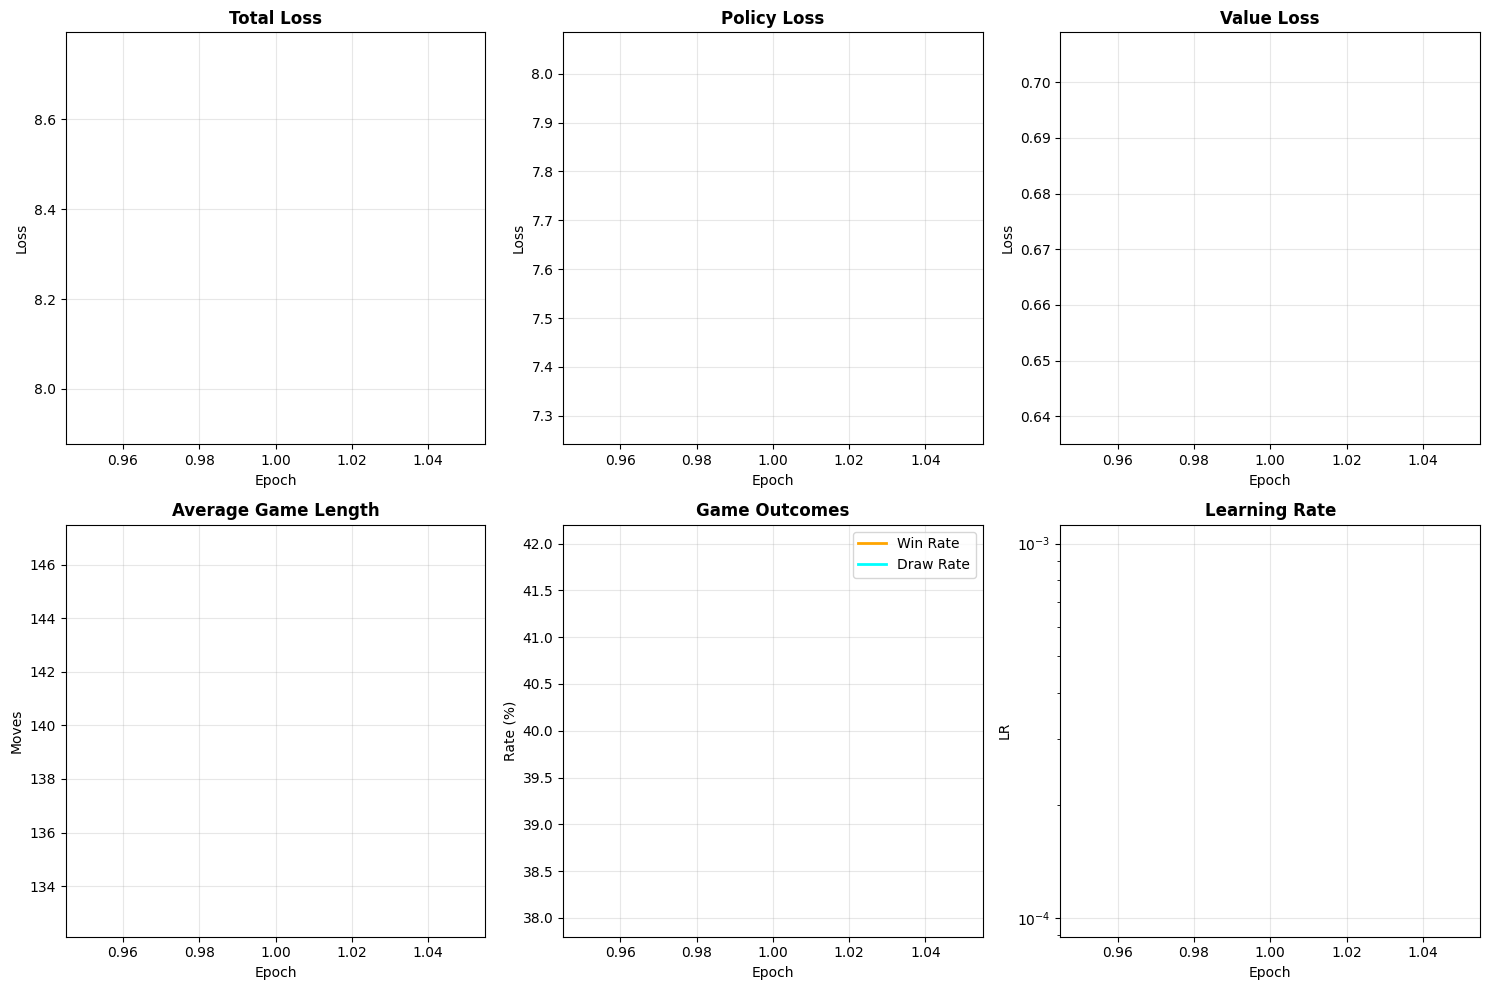

[INFO] Training visualization saved as 'training_metrics.png'


In [ ]:
import matplotlib.pyplot as plt

# Plot training metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(training_metrics['epoch'], training_metrics['total_loss'], 'b-', linewidth=2)
axes[0, 0].set_title('Total Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(training_metrics['epoch'], training_metrics['policy_loss'], 'g-', linewidth=2)
axes[0, 1].set_title('Policy Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(training_metrics['epoch'], training_metrics['value_loss'], 'r-', linewidth=2)
axes[0, 2].set_title('Value Loss', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].grid(True, alpha=0.3)

# Game statistics
axes[1, 0].plot(training_metrics['epoch'], training_metrics['avg_game_length'], 'purple', linewidth=2)
axes[1, 0].set_title('Average Game Length', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Moves')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(training_metrics['epoch'], training_metrics['win_rate'], 'orange', linewidth=2, label='Win Rate')
axes[1, 1].plot(training_metrics['epoch'], training_metrics['draw_rate'], 'cyan', linewidth=2, label='Draw Rate')
axes[1, 1].set_title('Game Outcomes', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Rate (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(training_metrics['epoch'], training_metrics['lr'], 'brown', linewidth=2)
axes[1, 2].set_title('Learning Rate', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('LR')
axes[1, 2].set_yscale('log')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("[INFO] Training visualization saved as 'training_metrics.png'")
